Пример: **Связь между Полом и Предпочтениями в Кино**

Предположим, вы хотите проверить, есть ли связь между полом (мужчина/женщина) и предпочтениями в кино (комедия/боевик). Вы собираете данные о 100 людях и получаете следующую таблицу сопряженности:

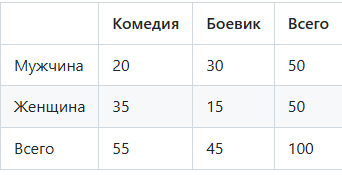

**Вопрос:** Есть ли статистически значимая связь между полом и предпочтениями в кино?

Импортируем необходимые библиотеки:

pandas для создания и работы с таблицей сопряженности.

scipy.stats для проведения хи-квадрат теста.

In [1]:
import pandas as pd
import scipy.stats as stats

Создается DataFrame observed, представляющий таблицу сопряженности с наблюдаемыми частотами.

Важно: замените этот пример своими реальными данными.

Строки представляют одну категориальную переменную (Пол),

 а столбцы – другую (Предпочтения в кино).

In [2]:
# Создадим таблицу сопряженности (contingency table) - ЗАМЕНИТЕ ЭТИМИ ВАШИМИ ДАННЫМИ
observed = pd.DataFrame({'Комедия': [20, 35], 'Боевик': [30, 15]},
                       index=['Мужчина', 'Женщина'])

print("Наблюдаемые частоты (таблица сопряженности):")
print(observed)

Наблюдаемые частоты (таблица сопряженности):
         Комедия  Боевик
Мужчина       20      30
Женщина       35      15


Функция stats.chi2_contingency(observed) выполняет хи-квадрат тест.

В функцию передается таблица сопряженности observed.

Функция возвращает:
* chi2: Хи-квадрат статистика.
* p: P-значение.
* dof: Степени свободы.
* expected: Таблица с ожидаемыми частотами.


In [3]:
# Проведение хи-квадрат теста
chi2, p, dof, expected = stats.chi2_contingency(observed)

print("\nРезультаты хи-квадрат теста:")
print(f"Хи-квадрат статистика: {chi2}")
print(f"P-значение: {p}")
print(f"Степени свободы: {dof}")
print("\nОжидаемые частоты:")
print(pd.DataFrame(expected, index=observed.index, columns=observed.columns))


Результаты хи-квадрат теста:
Хи-квадрат статистика: 7.919191919191919
P-значение: 0.004891311452359333
Степени свободы: 1

Ожидаемые частоты:
         Комедия  Боевик
Мужчина     27.5    22.5
Женщина     27.5    22.5


Сравниваем p-значение с уровнем значимости (alpha), который обычно равен 0.05.

Если p < alpha, то мы отвергаем нулевую гипотезу о независимости и заключаем, что существует статистически значимая связь между переменными.

Если p >= alpha, то мы не отвергаем нулевую гипотезу и заключаем, что нет достаточных доказательств для утверждения о существовании связи между переменными.

In [4]:
# Интерпретация результатов
alpha = 0.05  # Уровень значимости
print("\nИнтерпретация:")
if p < alpha:
    print("P-значение меньше уровня значимости.")
    print("Существует статистически значимая связь между полом и предпочтениями в кино.")
    print("Мы отвергаем нулевую гипотезу о независимости.")
else:
    print("P-значение больше уровня значимости.")
    print("Нет достаточных доказательств, чтобы утверждать о существовании связи между полом и предпочтениями в кино.")
    print("Мы не отвергаем нулевую гипотезу о независимости.")


Интерпретация:
P-значение меньше уровня значимости.
Существует статистически значимая связь между полом и предпочтениями в кино.
Мы отвергаем нулевую гипотезу о независимости.


Ожидаемые частоты вычисляются по формуле:

Ожидаемая частота = (Сумма строки * Сумма столбца) / Общая сумма

Например, ожидаемая частота для мужчин, предпочитающих комедии:


(50 * 55) / 100 = 27.5

Пример с поправкой Йетса (Yates’ correction):

Поправка Йетса используется для коррекции хи-квадрат статистики, когда ожидаемые частоты в некоторых ячейках таблицы сопряженности невелики (обычно меньше 5).

Она применяется, чтобы уменьшить вероятность ложноположительного результата.

Многие библиотеки (включая scipy.stats) автоматически применяют эту поправку для таблиц 2x2.

Чтобы отключить ее, используйте correction=False в функции chi2_contingency:

In [5]:
chi2, p, dof, expected = stats.chi2_contingency(observed, correction=False) # Отключаем поправку Йетса

Точный тест Фишера (Fisher’s Exact Test):


Точный тест Фишера является альтернативой хи-квадрат тесту, который используется, когда размеры выборки малы или когда ожидаемые частоты очень малы. Он особенно полезен для таблиц 2x2.

 Он не требует приближений, как хи-квадрат тест, и поэтому более точен, когда данные не соответствуют требованиям хи-квадрат теста.

In [6]:
oddsratio, pvalue = stats.fisher_exact(observed)
print(f"P-значение (точный тест Фишера): {pvalue}")

P-значение (точный тест Фишера): 0.004635020180798911
